## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer

pd.set_option('display.max_colwidth', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = Path('..') / 'data' / 'raw' / 'SciDCC.csv'
assert DATA_PATH.exists(), f'Nema datasetu na: {DATA_PATH.resolve()}'

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (11539, 7)


,Date,Link,Title,Summary,Body,Category,Year
0,"April 15, 2021",https://www.sciencedaily.com/releases/2021/04/210415114202.htm,Impacts of coronavirus lockdowns: New study collects data on pollutants in the atmosphere,"One consequence of the coronavirus pandemic has been global restrictions on mobility. This, in turn, has had an effect on pollution levels in the atmosphere. Researchers from across the world are ...","The meta-analysis was coordinated by Prof. Astrid Kiendler-Scharr, director at Jülich's Institute of Climate and Energy Research -- Troposphere. The analysis covers the measurement data of around ...",Ozone Holes,2021
1,"April 5, 2021",https://www.sciencedaily.com/releases/2021/04/210405123308.htm,"Ozone pollution harms maize crops, study finds","Although stratospheric ozone protects us by filtering out the sun's ultraviolet radiation, tropospheric ozone is a harmful pollutant. A new study has shown that ozone in the lower layers of the at...","Ozone is formed when nitrous oxide, released from industries and tail pipes of cars, is broken down by sunlight and chemically reacts to form ozone. Researchers at the University of Illinois Urban...",Ozone Holes,2021
2,"December 2, 2020",https://www.sciencedaily.com/releases/2020/12/201202114540.htm,Ozone breaks down THC deposited on surfaces from thirdhand cannabis smoke,"Second- and thirdhand tobacco smoke have received lots of attention, but much less is known about the compounds deposited on surfaces from cannabis smoke. Now, researchers reporting in ACS'","Smoking emits reactive chemicals that remain in the air (so-called secondhand smoke) or deposit onto surfaces, including walls, windows, clothing and upholstery (thirdhand smoke). Unlike the secon...",Ozone Holes,2020


## 2. Kvaliteta podataka

In [3]:
# tipovi i missing
print(df.dtypes)
print()
print('Missing:')
print(df.isna().sum())

Date        object
Link        object
Title       object
Summary     object
Body        object
Category    object
Year         int64
dtype: object

Missing:
Date        0
Link        0
Title       0
Summary     0
Body        5
Category    0
Year        0
dtype: int64


In [4]:
# duplikati (Link je URL pa bi trebao biti unique)
print(f'Dup po Link:  {df.duplicated(subset=["Link"]).sum()}')
print(f'Dup po Title: {df.duplicated(subset=["Title"]).sum()}')
print(f'Full dup:     {df.duplicated().sum()}')

Dup po Link:  0
Dup po Title: 4
Full dup:     0


In [5]:
print(f'Godine: {df["Year"].min()}..{df["Year"].max()}')
df['Year'].value_counts().sort_index().tail(10)

Godine: 1997..2021


Year
2012     240
2013     275
2014     347
2015     295
2016     405
2017     570
2018    1141
2019    1718
2020    3771
2021    1978
Name: count, dtype: int64

Izbacujem redove s praznim `Body` (to je glavni tekst) i duplikate po `Link`.

In [6]:
before = len(df)
df_clean = df.dropna(subset=['Body']).drop_duplicates(subset=['Link']).reset_index(drop=True)
print(f'{before} -> {len(df_clean)}  (uklonjeno {before - len(df_clean)})')

11539 -> 11534  (uklonjeno 5)


## 3. Distribucija klasa

In [7]:
class_counts = df_clean['Category'].value_counts()
print(f'Broj klasa: {len(class_counts)}')
print(f'Min/max:    {class_counts.min()} / {class_counts.max()}')
print(f'Omjer:      {class_counts.max() / class_counts.min():.1f}x')
print(f'Medijan:    {class_counts.median():.0f}')
print()
print(class_counts)

Broj klasa: 20
Min/max:    21 / 984
Omjer:      46.9x
Medijan:    622

Category
Earthquakes             984
Pollution               945
Genetically Modified    914
Agriculture & Food      844
Hurricanes Cyclones     842
Animals                 758
Weather                 719
Endangered Animals      701
Climate                 699
Ozone Holes             623
Biology                 620
New Species             527
Environment             478
Biotechnology           460
Geography               407
Microbes                398
Extinction              356
Zoology                 210
Geology                  28
Global Warming           21
Name: count, dtype: int64


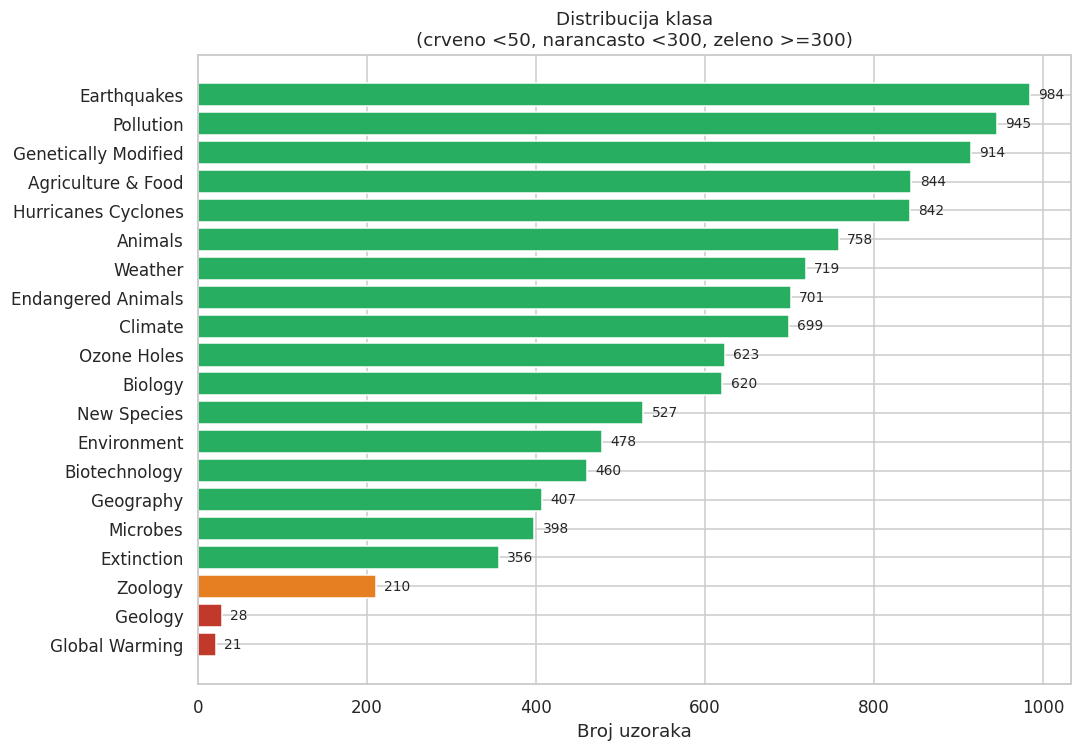

In [8]:
# boja po velicini klase
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if c < 50 else '#e67e22' if c < 300 else '#27ae60' for c in class_counts.values]
ax.barh(class_counts.index[::-1], class_counts.values[::-1], color=colors[::-1])
ax.set_xlabel('Broj uzoraka')
ax.set_title('Distribucija klasa\n(crveno <50, narancasto <300, zeleno >=300)')
for i, v in enumerate(class_counts.values[::-1]):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
# klase ispod 50 ce biti problematicne za stratified split
THRESHOLD = 50
small = class_counts[class_counts < THRESHOLD]
print(f'Klase s manje od {THRESHOLD}:')
print(small)
print(f'\nUkupno uzoraka u malim klasama: {small.sum()} ({small.sum()/len(df_clean)*100:.2f}%)')

Klase s manje od 50:
Category
Geology           28
Global Warming    21
Name: count, dtype: int64

Ukupno uzoraka u malim klasama: 49 (0.42%)


## 4. Duljine tekstova (word count kao prvi proxy)

In [10]:
for col in ['Title', 'Summary', 'Body']:
    df_clean[f'{col}_words'] = df_clean[col].astype(str).str.split().str.len()

df_clean['Combined_words'] = (
    df_clean['Title'].astype(str) + ' ' +
    df_clean['Summary'].astype(str) + ' ' +
    df_clean['Body'].astype(str)
).str.split().str.len()

df_clean[['Title_words', 'Summary_words', 'Body_words', 'Combined_words']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

,Title_words,Summary_words,Body_words,Combined_words
count,11534.0,11534.0,11534.0,11534.0
mean,9.3,47.0,522.7,579.0
std,2.7,25.5,220.4,223.0
min,2.0,0.0,4.0,13.0
25%,7.0,29.0,368.0,422.0
50%,9.0,41.0,494.0,551.0
75%,11.0,59.0,644.8,703.0
90%,13.0,80.0,806.0,868.0
95%,14.0,97.0,918.4,980.0
99%,16.0,130.0,1189.0,1247.7


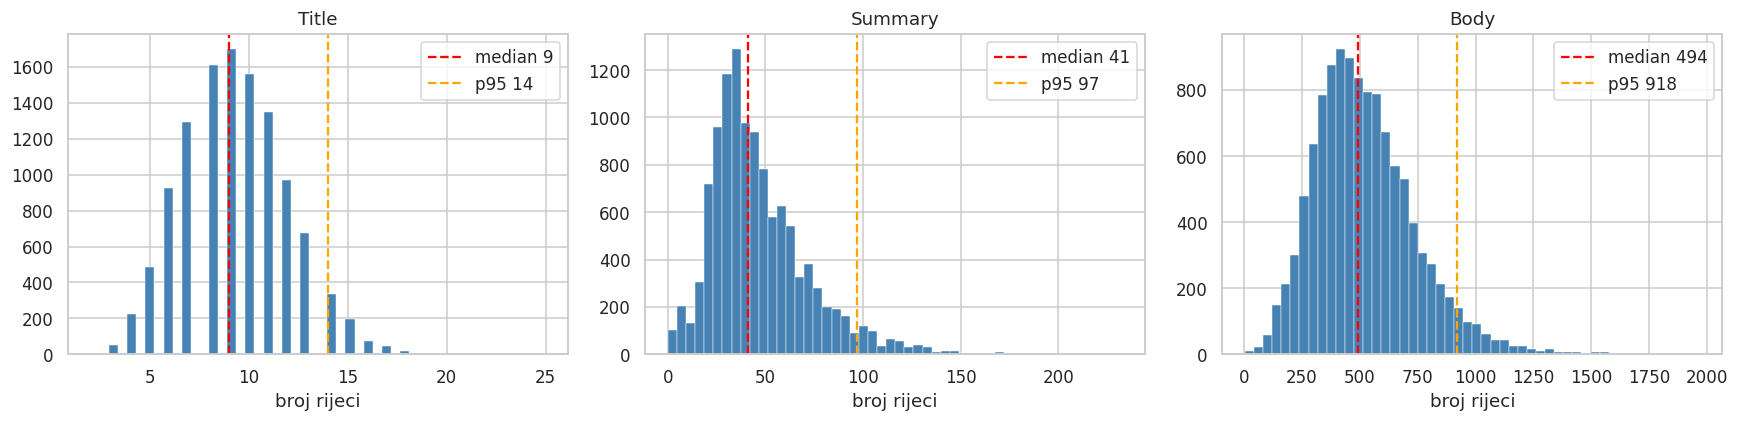

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Title_words', 'Summary_words', 'Body_words']):
    data = df_clean[col]
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'median {data.median():.0f}')
    ax.axvline(data.quantile(0.95), color='orange', linestyle='--', label=f'p95 {data.quantile(0.95):.0f}')
    ax.set_title(col.replace('_words', ''))
    ax.set_xlabel('broj rijeci')
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Tocno brojanje BERT tokena

Word count je samo priblizno. Subword tokenizacija (posebno za znanstvene termine, kemijske formule i brojeve) moze dati znatno vise tokena od broja rijeci. Koristim CliSciBERT tokenizer jer je isti i za NER i planiran za klasifikaciju.

In [12]:
TOKENIZER_MODEL = 'P0L3/cliscibert_scivocab_uncased'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)
print(f'Vocab size: {tokenizer.vocab_size}')

Vocab size: 31090


In [13]:
# batched, bez special tokena jer BERT pri inputu dodaje CLS/SEP pa bi +2 bilo duplo
def count_tokens(texts, batch_size=64):
    counts = []
    texts = list(texts)
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, add_special_tokens=False, truncation=False)
        counts.extend(len(ids) for ids in enc['input_ids'])
    return counts

df_clean['Title_tokens']   = count_tokens(df_clean['Title'].astype(str))
df_clean['Summary_tokens'] = count_tokens(df_clean['Summary'].astype(str))
print('Body token counting (traje malo)...')
df_clean['Body_tokens']    = count_tokens(df_clean['Body'].astype(str))
print('done')

Body token counting (traje malo)...
done


In [14]:
df_clean[['Title_tokens', 'Summary_tokens', 'Body_tokens']].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

,Title_tokens,Summary_tokens,Body_tokens
count,11534.0,11534.0,11534.0
mean,11.9,59.1,680.8
std,3.8,32.4,291.0
min,3.0,0.0,4.0
50%,12.0,52.0,642.0
75%,14.0,74.0,841.0
90%,17.0,102.0,1052.7
95%,19.0,122.0,1202.0
99%,22.0,164.7,1573.7
max,33.0,288.0,2819.0


In [15]:
# efektivni limit je 510 (CLS + SEP zauzmu 2)
EFFECTIVE_LIMIT = 510
for col in ['Title_tokens', 'Summary_tokens', 'Body_tokens']:
    pct = (df_clean[col] <= EFFECTIVE_LIMIT).mean() * 100
    print(f'{col:18s}  {pct:5.1f}% stane u 510')

Title_tokens        100.0% stane u 510
Summary_tokens      100.0% stane u 510
Body_tokens          30.1% stane u 510


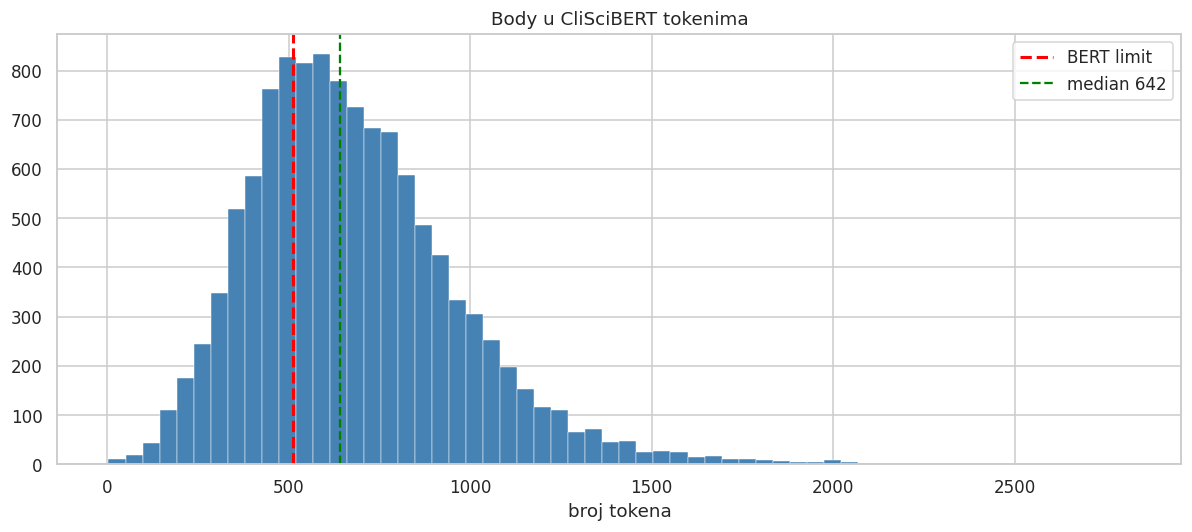

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df_clean['Body_tokens'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(512, color='red', linestyle='--', linewidth=2, label='BERT limit')
ax.axvline(df_clean['Body_tokens'].median(), color='green', linestyle='--', label=f'median {df_clean["Body_tokens"].median():.0f}')
ax.set_xlabel('broj tokena')
ax.set_title('Body u CliSciBERT tokenima')
ax.legend()
plt.tight_layout()
plt.show()

Vecina Body tekstova ne stane u 512. Opcije za truncation:

1. Head (default HuggingFace): prvih 512. U novinskim clancima glavna informacija dolazi rano.
2. Head + tail: npr. 256 + 256. Zakljucci znaju biti na kraju.
3. Title + Summary, bez Body: garantirano stane, Summary cesto najinformativniji.
4. Sliding window + agregacija logitsa: skupo, ali koristi cijeli tekst.

Plan: prvo (3) kao brzi baseline, pa (1) s Body, usporedba. Ako Body znacajno bolji, probat cu (2).

## 6. Duljina po klasi

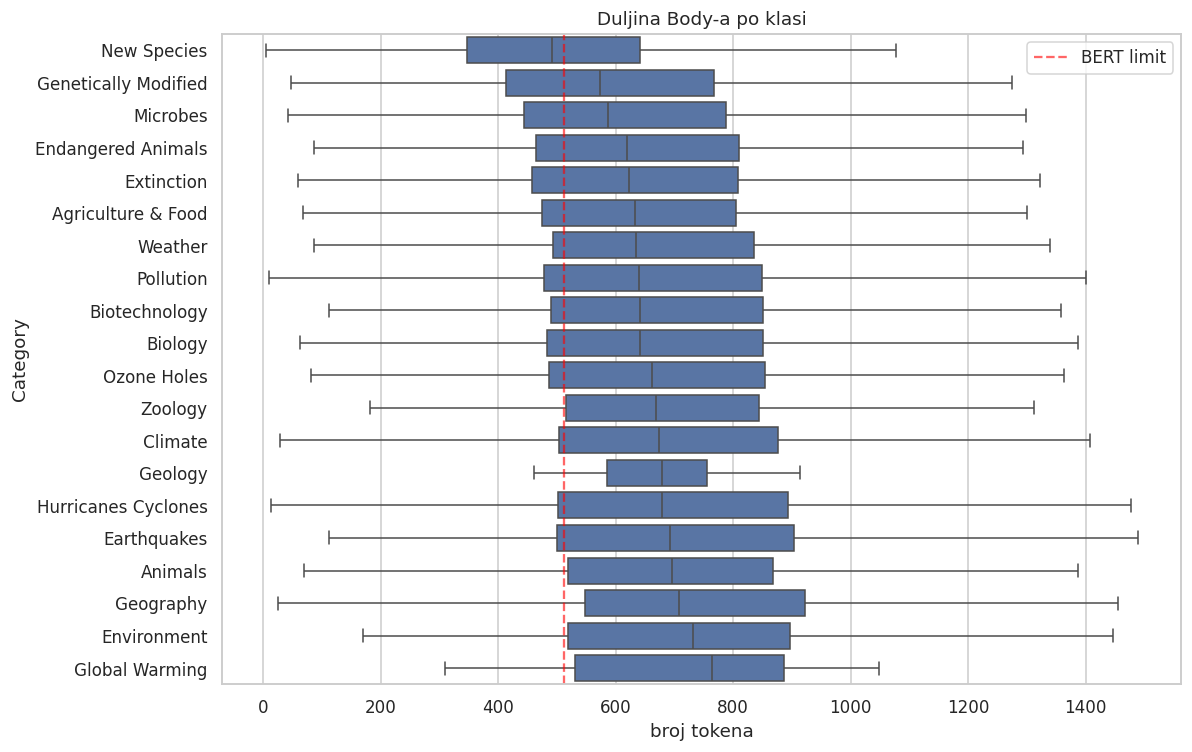

In [17]:
# provjera da neke klase nemaju sistematski drukcije duljine (potencijalni confound)
fig, ax = plt.subplots(figsize=(11, 7))
order = df_clean.groupby('Category')['Body_tokens'].median().sort_values().index
sns.boxplot(data=df_clean, y='Category', x='Body_tokens', order=order, ax=ax, showfliers=False)
ax.axvline(512, color='red', linestyle='--', alpha=0.6, label='BERT limit')
ax.set_title('Duljina Body-a po klasi')
ax.set_xlabel('broj tokena')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Distribucija kroz godine

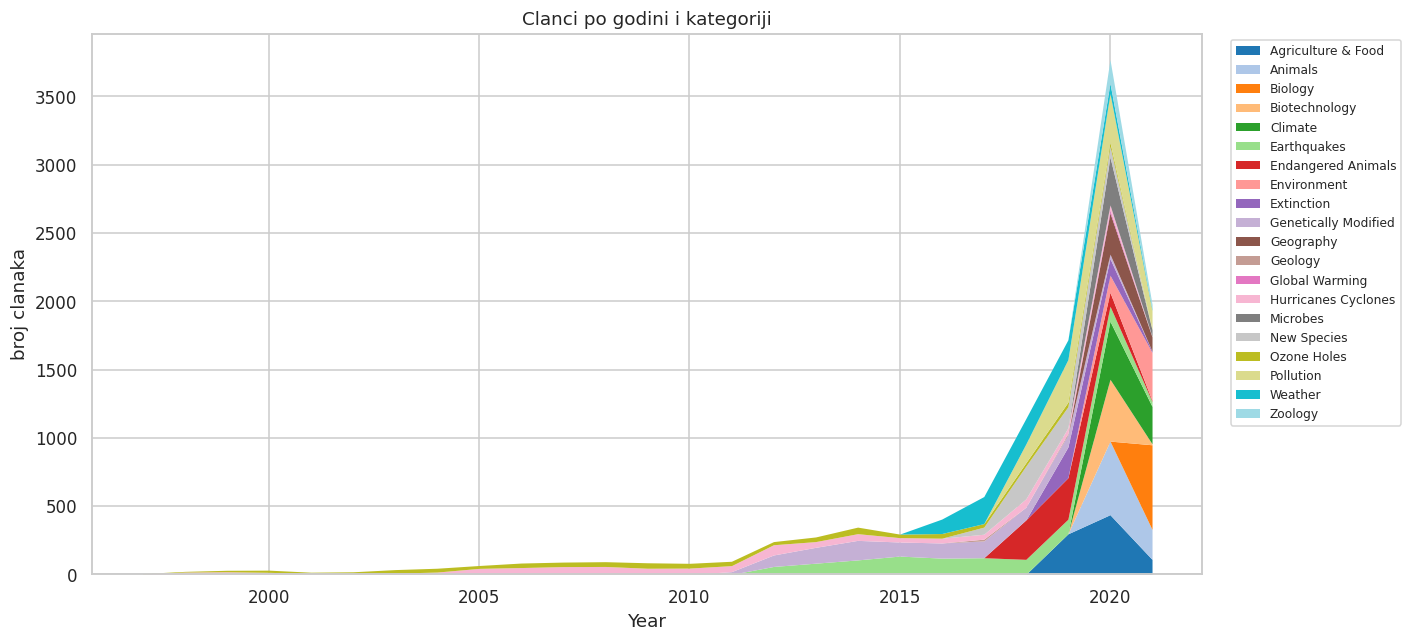

In [18]:
year_category = df_clean.groupby(['Year', 'Category']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 6))
year_category.plot(kind='area', stacked=True, ax=ax, colormap='tab20', linewidth=0)
ax.set_title('Clanci po godini i kategoriji')
ax.set_ylabel('broj clanaka')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

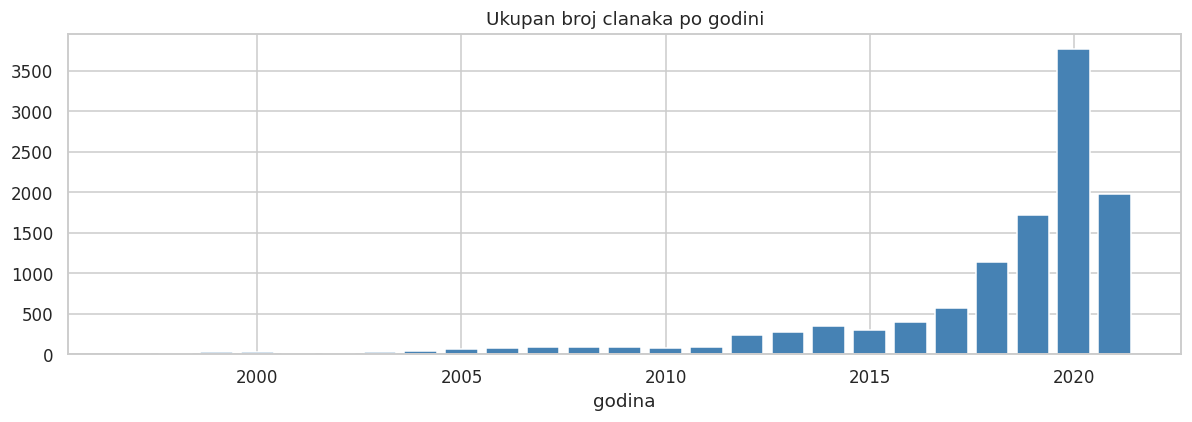

In [19]:
yearly = df_clean['Year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(yearly.index, yearly.values, color='steelblue')
ax.set_title('Ukupan broj clanaka po godini')
ax.set_xlabel('godina')
plt.tight_layout()
plt.show()

## 8. Primjeri po klasi

Rucna provjera: koje klase imaju semanticko preklapanje (npr. `Climate` vs `Global Warming` vs `Weather`).

In [20]:
for cat in sorted(df_clean['Category'].unique()):
    sub = df_clean[df_clean['Category'] == cat]
    sample = sub['Title'].sample(min(2, len(sub)), random_state=42).tolist()
    print(f'\n[{cat}] ({class_counts[cat]})')
    for s in sample:
        print(f'  * {s}')


[Agriculture & Food] (844)
  * Climate-driven farming 'frontiers' pose major environmental risks
  * How plants ensure regular seed spacing

[Animals] (758)
  * Wind farms on the Black Sea coast could endanger bat populations in Eastern Europe
  * Birds learn to avoid flashy, hard-to-catch butterflies and their lookalikes

[Biology] (620)
  * A new strain of a well-known probiotic might offer help for infants' intestinal problems
  * A beginner's guide to DNA origami

[Biotechnology] (460)
  * How organ functions were shaped over the course of evolution
  * Engineers reveal molecular secrets of cephalopod powers

[Climate] (699)
  * Novel photocatalyst effectively turns carbon dioxide into methane fuel with light
  * Energy system 2050: Solutions for the energy transition

[Earthquakes] (984)
  * Age of blueschist is not an indicator of the date of emergence of plate tectonics
  * Bombay beach event demonstrates difficulties in earthquake swarm forecasting

[Endangered Animals] (701)


## 9. Spremanje cistog dataseta

In [21]:
import json

PROCESSED_DIR = Path('..') / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

out_path = PROCESSED_DIR / 'scidcc_clean.csv'
df_clean.to_csv(out_path, index=False)
print(f'Saved: {out_path.resolve()}  {df_clean.shape}')

# label mapping, sortiran alfabetski da bude deterministican
categories = sorted(df_clean['Category'].unique())
label2id = {cat: i for i, cat in enumerate(categories)}
id2label = {i: cat for i, cat in enumerate(categories)}

map_path = PROCESSED_DIR / 'label_map.json'
with open(map_path, 'w', encoding='utf-8') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2, ensure_ascii=False)
print(f'Saved: {map_path.resolve()}  ({len(categories)} klasa)')

Saved: /home/damki/climate-nlp-platform/data/processed/scidcc_clean.csv  (11534, 14)
Saved: /home/damki/climate-nlp-platform/data/processed/label_map.json  (20 klasa)
